# model.ipynb（任务3.1：基于 PNG 示例的功率谱参数估计）

本文件按你新指定的参考笔记本
`/pscratch/sd/l/lzy/1gpc-UNIT-fnl100-fastpm/pk-pcf-model/png_examples_for_quijote.ipynb`
重写，核心改动如下：

1. 使用当前项目功率谱路径：`/pscratch/sd/l/lzy/1gpc-UNIT-fnl100-fastpm/pk`
2. 输入文件模式：`pk_rsd_N*.dat`
3. 使用 `pypower.PowerSpectrumStatistics` 组织 `data + mocks`
4. 使用 `TracerPowerSpectrumMultipolesObservable` + `ObservablesGaussianLikelihood`
5. 协方差修正不手动实现（不再自己乘 Hartlap 因子），交给 desilike 在观测量/似然层处理

> 注：本 notebook 为“代码交付版”，默认包含拟合调用，但你可以先只运行到 likelihood 初始化检查数据与模型是否连通。

In [1]:
# ============================================================
# 代码大纲（执行逻辑关系）
# A. 读取功率谱文件：
#    - 批量读取 pk_rsd_N*.dat
#    - 取第1列 kcen、第2/3列 kmin/kmax、第6列 P0
#    - 拼成 (Nmock, Nbin) 的 P0 样本矩阵
# B. 构建 pypower 统计对象：
#    - 用均值曲线构造 data（PowerSpectrumStatistics）
#    - 用每个 realization 构造 mocks 列表
# C. 构建 desilike 理论模型与似然：
#    - FixedPowerSpectrumTemplate + PNGTracerPowerSpectrumMultipoles
#    - TracerPowerSpectrumMultipolesObservable(data, covariance=mocks, klim)
#    - ObservablesGaussianLikelihood
# D. 参数拟合：
#    - 用 MinuitProfiler 得到 best-fit
# E. 可视化：
#    - observable 原生 plot
#    - 手动画 Data 与 Best-fit 对比图
# ============================================================

import os
import re
import glob
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# =====================
# 参数区（统一放在最前面，便于改动）
# =====================

# FastPM 功率谱输入目录（默认改为 3Gpc fnl100）
DATA_DIR = '/pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pk_masscut'
FILE_GLOB = 'pk_rsd_3gpc_fnl100_N*.dat'

# FastPM covariance 数据来源（允许与 data 的 fnl 不同）
FASTPM_COV_DATA_DIR = '/pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pk_masscut'
FASTPM_COV_FILE_GLOB = 'pk_rsd_3gpc_fnl0_N*.dat'

# realization 选择范围（闭区间）
REALIZATION_MIN = 2
REALIZATION_MAX = 99

# 使用前多少个 k-bin 进入拟合
# 3Gpc 当前网格下，前 26 个点大致对应到 k~0.08
N_DATAPOINTS = 20

# 列索引（对应 POWSPEC 输出）
# col0: kcen, col1: kmin, col2: kmax, col5: P0
K_CEN_COL = 0
K_MIN_COL = 1
K_MAX_COL = 2
P0_COL = 5

# 协方差设置
# True: 仅使用 FastPM realization 样本估计 covariance（不使用 EZmock）
USE_FASTPM_COV_ONLY = True

# 若后续需要切回 EZmock 协方差，可保留以下路径备用
COV_MOCK_GLOB = '/pscratch/sd/l/lzy/cov_mock/B3000G768Z0N4417983_b0.18d5r270c1.65_seed*/PK_EZmock_B3000G768Z0N4417983_b0.18d5r270c1.65_seed*_RSD.dat'
EZ_K_COL = 0
EZ_P0_COL = 5

# 理论模型参数
UNIT_Z = 1.0
FIXED_P = 1.2
FIXED_SN0 = 0.0
FIXED_SIGMAS = 0.0

# 拟合参数
MINUIT_SEED = 66
MINUIT_NITER = 27

print('参数加载完成。')
print(f'DATA_DIR = {DATA_DIR}')
print(f'realization 范围 = [{REALIZATION_MIN}, {REALIZATION_MAX}]')
print(f'N_DATAPOINTS = {N_DATAPOINTS}')
print(f'USE_FASTPM_COV_ONLY = {USE_FASTPM_COV_ONLY}')
print(f'FASTPM_COV_FILE_GLOB = {FASTPM_COV_FILE_GLOB}')
print(f'COV_MOCK_GLOB (备用) = {COV_MOCK_GLOB}')
# 功率谱图像展示范围（只影响画图，不改变输入数据文件）
PK_PLOT_KMAX = 1.0
PK_PLOT_NPTS = 400


参数加载完成。
DATA_DIR = /pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pk_masscut
realization 范围 = [2, 99]
N_DATAPOINTS = 20
USE_FASTPM_COV_ONLY = True
FASTPM_COV_FILE_GLOB = pk_rsd_3gpc_fnl0_N*.dat
COV_MOCK_GLOB (备用) = /pscratch/sd/l/lzy/cov_mock/B3000G768Z0N4417983_b0.18d5r270c1.65_seed*/PK_EZmock_B3000G768Z0N4417983_b0.18d5r270c1.65_seed*_RSD.dat


In [3]:
def parse_realization_id(filepath):
    """
    从文件名中解析 realization 编号。

    参数
    ----------
    filepath : str
        文件完整路径，例如 /.../pk_rsd_N18.dat

    返回
    ----------
    int
        解析出的编号；若解析失败，返回 -1。
    """
    name = os.path.basename(filepath)
    match = re.search(r'N([0-9]+)', name)
    return int(match.group(1)) if match else -1


def read_single_pk_file(filepath, n_datapoints, k_cen_col, k_min_col, k_max_col, p0_col):
    """
    读取单个功率谱文件并抽取所需列。

    参数
    ----------
    filepath : str
        输入文件路径。
    n_datapoints : int
        截取的 k-bin 数量（取前 n_datapoints 行）。
    k_cen_col, k_min_col, k_max_col, p0_col : int
        对应列索引。

    返回
    ----------
    tuple(ndarray, ndarray, ndarray, ndarray)
        kcen, kmin, kmax, p0，均为 shape (n_datapoints,)。
    """
    arr = np.loadtxt(filepath, comments='#')
    sl = slice(0, n_datapoints)
    kcen = arr[sl, k_cen_col]
    kmin = arr[sl, k_min_col]
    kmax = arr[sl, k_max_col]
    p0 = arr[sl, p0_col]
    return kcen, kmin, kmax, p0


def load_pk_ensemble(data_dir, file_glob, realization_min, realization_max,
                     n_datapoints, k_cen_col, k_min_col, k_max_col, p0_col):
    """
    批量读取功率谱 realization，并构建 data/mocks 所需基础数组。

    参数
    ----------
    data_dir : str
        功率谱文件目录。
    file_glob : str
        文件匹配模式，如 pk_rsd_N*.dat。
    realization_min, realization_max : int
        realization 编号范围（闭区间）。
    n_datapoints : int
        每个 realization 截取前多少个 k-bin。
    k_cen_col, k_min_col, k_max_col, p0_col : int
        对应数据列索引。

    返回
    ----------
    dict
        包含 kcen, kmin, kmax, p0_mocks, p0_mean, used_files。
        - kcen/kmin/kmax: shape (n_datapoints,)
        - p0_mocks: shape (n_mock, n_datapoints)
        - p0_mean: shape (n_datapoints,)
    """
    pattern = os.path.join(data_dir, file_glob)
    files = sorted(glob.glob(pattern), key=parse_realization_id)

    selected = []
    for fp in files:
        rid = parse_realization_id(fp)
        if realization_min <= rid <= realization_max:
            selected.append(fp)

    if not selected:
        raise FileNotFoundError(
            f'未找到可用输入文件：{pattern}，范围=[{realization_min},{realization_max}]'
        )

    p0_list = []

    # 直接使用第一个文件的 k 网格作为参考
    ref_kcen, ref_kmin, ref_kmax, _ = read_single_pk_file(
        filepath=selected[0],
        n_datapoints=n_datapoints,
        k_cen_col=k_cen_col,
        k_min_col=k_min_col,
        k_max_col=k_max_col,
        p0_col=p0_col,
    )

    for fp in selected:
        _, _, _, p0 = read_single_pk_file(
            filepath=fp,
            n_datapoints=n_datapoints,
            k_cen_col=k_cen_col,
            k_min_col=k_min_col,
            k_max_col=k_max_col,
            p0_col=p0_col,
        )
        p0_list.append(p0)

    p0_mocks = np.asarray(p0_list, dtype=np.float64)
    p0_mean = np.mean(p0_mocks, axis=0)

    print('功率谱样本读取完成：')
    print(f'  mock 数量 = {p0_mocks.shape[0]}')
    print(f'  k-bin 数量 = {p0_mocks.shape[1]}')
    print(f'  k 范围 = [{ref_kcen.min():.5f}, {ref_kcen.max():.5f}]')

    return {
        'kcen': ref_kcen,
        'kmin': ref_kmin,
        'kmax': ref_kmax,
        'p0_mocks': p0_mocks,
        'p0_mean': p0_mean,
        'used_files': selected,
    }


功率谱样本读取完成：
  mock 数量 = 98
  k-bin 数量 = 20
  k 范围 = [0.00350, 0.06050]


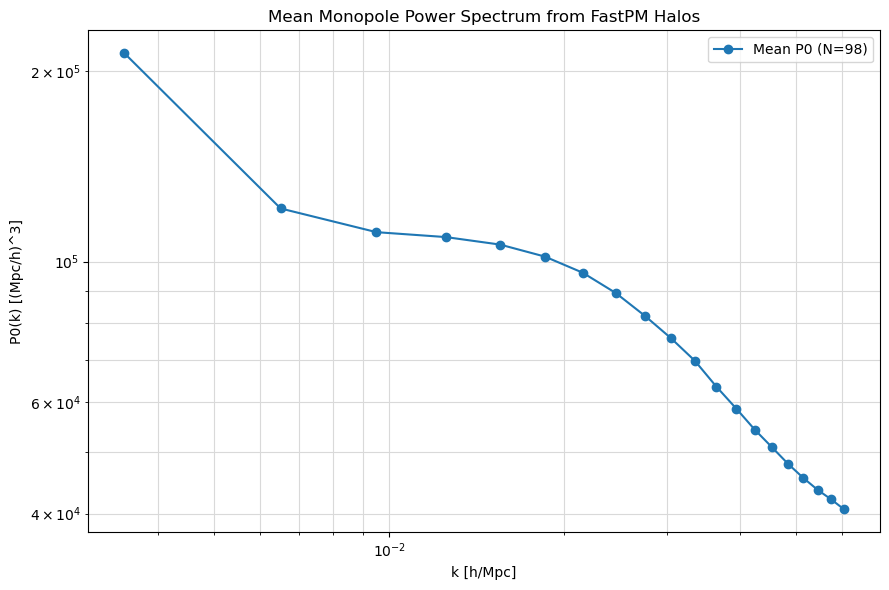

In [4]:
# 执行批量读取
pk_data = load_pk_ensemble(
    data_dir=DATA_DIR,
    file_glob=FILE_GLOB,
    realization_min=REALIZATION_MIN,
    realization_max=REALIZATION_MAX,
    n_datapoints=N_DATAPOINTS,
    k_cen_col=K_CEN_COL,
    k_min_col=K_MIN_COL,
    k_max_col=K_MAX_COL,
    p0_col=P0_COL,
)

k_values = pk_data['kcen']
kmins = pk_data['kmin']
kmaxs = pk_data['kmax']
p0_mocks = pk_data['p0_mocks']
p0_mean = pk_data['p0_mean']

plt.figure(figsize=(9, 6))
plt.loglog(k_values, p0_mean, 'o-', color='tab:blue', label=f'Mean P0 (N={p0_mocks.shape[0]})')
plt.grid(True, which='both', ls='-', color='0.85')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P0(k) [(Mpc/h)^3]')
plt.title('Mean Monopole Power Spectrum from FastPM Halos')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
from pypower import PowerSpectrumStatistics


def load_ezmock_covariance_p0(k_target, n_datapoints, cov_mock_glob, ez_k_col=0, ez_p0_col=5):
    """
    读取 EZmock 功率谱样本，构建用于 covariance 的 P0 mock 矩阵。
    仅在 USE_FASTPM_COV_ONLY=False 时使用。
    """
    files = sorted(glob.glob(cov_mock_glob), key=parse_realization_id)
    if len(files) == 0:
        raise FileNotFoundError(f'未找到 EZmock 协方差文件：{cov_mock_glob}')

    p0_list = []
    used_files = []
    skipped = 0

    for fp in files:
        try:
            arr = np.loadtxt(fp, comments='#')
            if arr.ndim != 2 or arr.shape[0] < n_datapoints:
                skipped += 1
                continue

            k_in = arr[:n_datapoints, ez_k_col]
            p0_in = arr[:n_datapoints, ez_p0_col]

            if np.allclose(k_in, k_target, rtol=0.0, atol=1e-10):
                p0_use = p0_in
            else:
                p0_use = np.interp(k_target, arr[:, ez_k_col], arr[:, ez_p0_col])

            if not np.all(np.isfinite(p0_use)):
                skipped += 1
                continue

            p0_list.append(p0_use)
            used_files.append(fp)
        except Exception:
            skipped += 1

    if len(p0_list) == 0:
        raise RuntimeError('EZmock 协方差样本为空：所有文件均不可用。')

    p0_cov_mocks = np.asarray(p0_list, dtype=np.float64)
    return p0_cov_mocks, used_files, skipped


def build_pypower_data_and_mocks(kcen, kmin, kmax, p0_mean_data, p0_cov_mocks):
    """
    把 data 与 covariance mock 封装成 desilike 可识别的 pypower 统计对象。

    当前默认口径：
    - data 使用 fastPM 的均值曲线；
    - covariance 使用 fastPM realization 样本（不使用 EZmock）。
    """
    edges = np.concatenate([kmin, [kmax[-1]]])
    ells = [0]
    nmodes = 4.0 * np.pi / 3.0 * (edges[1:]**3 - edges[:-1]**3)

    poles_mean = np.asarray([p0_mean_data], dtype='f8')
    data_ps = PowerSpectrumStatistics(
        edges=edges,
        modes=kcen,
        power_nonorm=poles_mean,
        nmodes=nmodes,
        ells=ells,
        shotnoise_nonorm=0.0,
        statistic='multipole',
    )

    mock_ps_list = []
    for i in range(p0_cov_mocks.shape[0]):
        tmp = data_ps.deepcopy()
        tmp.power_nonorm.flat[...] = np.asarray([p0_cov_mocks[i]], dtype='f8').ravel()
        mock_ps_list.append(tmp)

    return data_ps, mock_ps_list


# data 一直使用 fastPM 平均值
# covariance 按开关选择：默认只用 fastPM 样本
if USE_FASTPM_COV_ONLY:
    # 允许 covariance 与 data 使用不同 fnl 样本（例如 data=fnl100, cov=fnl0）
    cov_pk = load_pk_ensemble(
        data_dir=FASTPM_COV_DATA_DIR,
        file_glob=FASTPM_COV_FILE_GLOB,
        realization_min=REALIZATION_MIN,
        realization_max=REALIZATION_MAX,
        n_datapoints=N_DATAPOINTS,
        k_cen_col=K_CEN_COL,
        k_min_col=K_MIN_COL,
        k_max_col=K_MAX_COL,
        p0_col=P0_COL,
    )

    if len(cov_pk['kcen']) != len(k_values) or not np.allclose(cov_pk['kcen'], k_values, rtol=0.0, atol=1e-10):
        raise ValueError('FastPM covariance k-grid 与 data k-grid 不一致，请检查文件与 n_datapoints 设置。')

    p0_cov_mocks = np.asarray(cov_pk['p0_mocks'], dtype=np.float64)
    cov_used_files = list(cov_pk['used_files'])
    cov_skipped = 0
    cov_label = f"FastPM ({FASTPM_COV_FILE_GLOB})"
else:
    p0_cov_mocks, cov_used_files, cov_skipped = load_ezmock_covariance_p0(
        k_target=k_values,
        n_datapoints=N_DATAPOINTS,
        cov_mock_glob=COV_MOCK_GLOB,
        ez_k_col=EZ_K_COL,
        ez_p0_col=EZ_P0_COL,
    )
    cov_label = 'EZmock'


data_ps, mock_ps_list = build_pypower_data_and_mocks(
    kcen=k_values,
    kmin=kmins,
    kmax=kmaxs,
    p0_mean_data=p0_mean,
    p0_cov_mocks=p0_cov_mocks,
)

print('data_ps 构建完成。')
print(f'  fastPM data 点数 = {p0_mean.size}')
print(f'  covariance 来源 = {cov_label}')
print(f'  covariance mock 数量 = {len(mock_ps_list)}')
print(f'  covariance 跳过文件数 = {cov_skipped}')


功率谱样本读取完成：
  mock 数量 = 98
  k-bin 数量 = 20
  k 范围 = [0.00350, 0.06050]
data_ps 构建完成。
  fastPM data 点数 = 20
  covariance 来源 = FastPM (pk_rsd_3gpc_fnl0_N*.dat)
  covariance mock 数量 = 98
  covariance 跳过文件数 = 0


In [6]:
from cosmoprimo import Cosmology
from desilike import setup_logging
from desilike.theories.galaxy_clustering import FixedPowerSpectrumTemplate, PNGTracerPowerSpectrumMultipoles
from desilike.observables.galaxy_clustering import TracerPowerSpectrumMultipolesObservable
from desilike.likelihoods import ObservablesGaussianLikelihood

# 初始化日志
setup_logging()

# 宇宙学设置（沿用你参考本中的参数体系）
cosmo_unit = Cosmology(
    h=0.6711,
    Omega_b=0.049,
    Omega_cdm=0.3175 - 0.049,
    sigma8=0.834,
    n_s=0.9624,
    engine='class',
)

# 理论模板与 PNG tracer 模型
template = FixedPowerSpectrumTemplate(z=UNIT_Z, fiducial=cosmo_unit)
theory = PNGTracerPowerSpectrumMultipoles(template=template, mode='b-p')

# 固定部分参数，留 fnl_loc 与 b1 拟合（与参考 notebook 思路一致）
theory.init.params['p'].update(fixed=True, value=FIXED_P)
theory.init.params['sn0'].update(fixed=True, value=FIXED_SN0)
# 放开 sigmas，让其参与拟合
theory.init.params['sigmas'].update(fixed=False, value=FIXED_SIGMAS)

# 构建 observable 与 likelihood
# 关键点：covariance 直接传 mock 列表，由 desilike 在内部处理有限样本协方差修正
# （包含你提到的 Hartlap / Percival 相关修正流程），这里不再手动乘修正因子。
observable = TracerPowerSpectrumMultipolesObservable(
    data=data_ps,
    covariance=mock_ps_list,
    klim={0: [float(k_values.min()), float(k_values.max()), float(k_values[1] - k_values[0])]},
    theory=theory,
)

likelihood = ObservablesGaussianLikelihood(observables=[observable])
_ = likelihood()  # 初始化

# 为避免 profiling 重新放开参数，在 likelihood 层再强制固定一次
likelihood.all_params['p'].update(fixed=True, value=FIXED_P)
likelihood.all_params['sn0'].update(fixed=True, value=FIXED_SN0)
# 在 likelihood 层也放开 sigmas
likelihood.all_params['sigmas'].update(fixed=False, value=FIXED_SIGMAS)
print('likelihood 初始化完成。')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[000001.01] [0/1] 03-15 23:31  ObservablesGaussianLikelihood INFO     Covariance matrix with 20 points built from 98 observations.
[000001.01] [0/1] 03-15 23:31  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.7835.
[000001.01] [0/1] 03-15 23:31  ObservablesGaussianLikelihood INFO     Covariance matrix with 20 points built from 98 observations, varying 3 parameters.
[000001.01] [0/1] 03-15 23:31  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.1642.
likelihood 初始化完成。


In [7]:
float(k_values.min())

0.0035

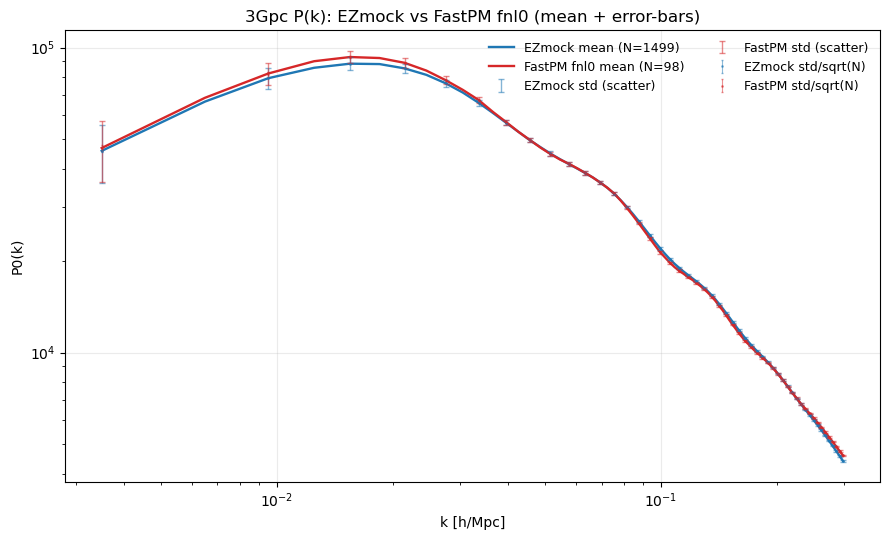

[EZmock]
  files found=1499, used=1499, skipped=0, 1/sqrt(N)=0.025828
[FastPM fnl0]
  files found=98, used=98, skipped=0, 1/sqrt(N)=0.101015
[k-grid] EZmock and FastPM k-centers are aligned.


In [8]:
# EZmock + FastPM(3Gpc fnl0) P(k) mean + error-bar check
import glob
import numpy as np
import matplotlib.pyplot as plt

EZ_PATTERN = '/pscratch/sd/l/lzy/cov_mock/B3000G768Z0N4417983_*/PK_EZmock_*_RSD.dat'
FASTPM_PATTERN = '/pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pk_masscut/pk_rsd_3gpc_fnl0_N*.dat'


def load_pk(fp):
    arr = np.loadtxt(fp, comments='#')
    return arr[:, 0], arr[:, 5]  # kcen, P0


def stack_pk(pattern, name, atol=1e-10):
    files = sorted(glob.glob(pattern))
    if len(files) == 0:
        raise FileNotFoundError(f'[{name}] no PK files matched: {pattern}')

    k_ref, p_ref = load_pk(files[0])
    pks = [p_ref]
    skipped = []

    for fp in files[1:]:
        try:
            k, p = load_pk(fp)
            if len(k) != len(k_ref) or not np.allclose(k, k_ref, rtol=0, atol=atol):
                skipped.append(fp)
                continue
            pks.append(p)
        except Exception:
            skipped.append(fp)

    pks = np.asarray(pks)
    n = pks.shape[0]
    mean = pks.mean(axis=0)
    std = pks.std(axis=0, ddof=1) if n > 1 else np.zeros_like(mean)
    sem = std / np.sqrt(n)
    return {
        'name': name,
        'files': files,
        'used': n,
        'skipped': skipped,
        'k': k_ref,
        'mean': mean,
        'std': std,
        'sem': sem,
    }


ez = stack_pk(EZ_PATTERN, 'EZmock')
fm = stack_pk(FASTPM_PATTERN, 'FastPM 3Gpc fnl0')

fig, ax = plt.subplots(figsize=(9, 5.5))
step_ez = 2
step_fm = 2

# mean curves
ax.plot(ez['k'], ez['mean'], color='tab:blue', lw=1.7, label=f"EZmock mean (N={ez['used']})")
ax.plot(fm['k'], fm['mean'], color='tab:red', lw=1.7, label=f"FastPM fnl0 mean (N={fm['used']})")

# std error bars (scatter)
ax.errorbar(ez['k'][::step_ez], ez['mean'][::step_ez], yerr=ez['std'][::step_ez], fmt='none',
            ecolor='tab:blue', alpha=0.55, elinewidth=1.0, capsize=2,
            label='EZmock std (scatter)')
ax.errorbar(fm['k'][::step_fm], fm['mean'][::step_fm], yerr=fm['std'][::step_fm], fmt='none',
            ecolor='tab:red', alpha=0.55, elinewidth=1.0, capsize=2,
            label='FastPM std (scatter)')

# sem guide points (optional visual reference)
ax.errorbar(ez['k'][::step_ez], ez['mean'][::step_ez], yerr=ez['sem'][::step_ez], fmt='.',
            ms=2, color='tab:blue', alpha=0.5, elinewidth=0.8, capsize=1,
            label='EZmock std/sqrt(N)')
ax.errorbar(fm['k'][::step_fm], fm['mean'][::step_fm], yerr=fm['sem'][::step_fm], fmt='.',
            ms=2, color='tab:red', alpha=0.5, elinewidth=0.8, capsize=1,
            label='FastPM std/sqrt(N)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P0(k)')
ax.set_title('3Gpc P(k): EZmock vs FastPM fnl0 (mean + error-bars)')
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

print('[EZmock]')
print(f"  files found={len(ez['files'])}, used={ez['used']}, skipped={len(ez['skipped'])}, 1/sqrt(N)={1/np.sqrt(ez['used']):.6f}")
print('[FastPM fnl0]')
print(f"  files found={len(fm['files'])}, used={fm['used']}, skipped={len(fm['skipped'])}, 1/sqrt(N)={1/np.sqrt(fm['used']):.6f}")
if len(ez['k']) == len(fm['k']) and np.allclose(ez['k'], fm['k'], rtol=0, atol=1e-10):
    print('[k-grid] EZmock and FastPM k-centers are aligned.')
else:
    print('[k-grid] EZmock and FastPM k-centers are NOT perfectly aligned (still plotted together).')


In [9]:
from desilike.profilers import MinuitProfiler

# 用 Minuit 做极大似然拟合
print('开始 Minuit profiling...')
profiler = MinuitProfiler(likelihood, seed=MINUIT_SEED)
profiles = profiler.maximize(niterations=MINUIT_NITER)

print('拟合统计：')
print(profiles.to_stats(tablefmt='pretty'))

# best-fit 参数字典
bestfit_params = profiles.bestfit.choice(input=True)
print('Best-fit 参数：')
print(bestfit_params)


开始 Minuit profiling...
[000007.54] [0/1] 03-15 23:31  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'b1', 'sigmas'].
[000007.55] [0/1] 03-15 23:31  ObservablesGaussianLikelihood INFO     Covariance matrix with 20 points built from 98 observations, varying 3 parameters.
[000007.55] [0/1] 03-15 23:31  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.1642.


[000008.21] [0/1] 03-15 23:31  MinuitProfiler            INFO     Successfully jit input likelihood.
拟合统计：
+------------------------------------+--------+---------+-------+
| chi2 / (20 - 3) = 0.92 / 17 = 0.05 | varied | bestfit | error |
+------------------------------------+--------+---------+-------+
|              fnl_loc               |  True  |  77.1   |  3.9  |
|                 b1                 |  True  |  2.790  | 0.020 |
|               sigmas               |  True  |   2.2   |  2.7  |
+------------------------------------+--------+---------+-------+
Best-fit 参数：
{'fnl_loc': ParameterArray(fnl_loc, None, 77.06874429325195), 'b1': ParameterArray(b1, None, 2.7896293424721748), 'sigmas': ParameterArray(sigmas, None, 2.1876032633469227), 'p': ParameterArray(p, None, 1.2), 'sn0': ParameterArray(sn0, None, 0.0)}


In [10]:
# 1) desilike 内置可视化（最稳妥）
observable.plot(interactive={'params': bestfit_params})

interactive(children=(FloatSlider(value=77.06874429325195, description='$f_{\\mathrm{NL}}^{\\mathrm{loc}}$ : '…

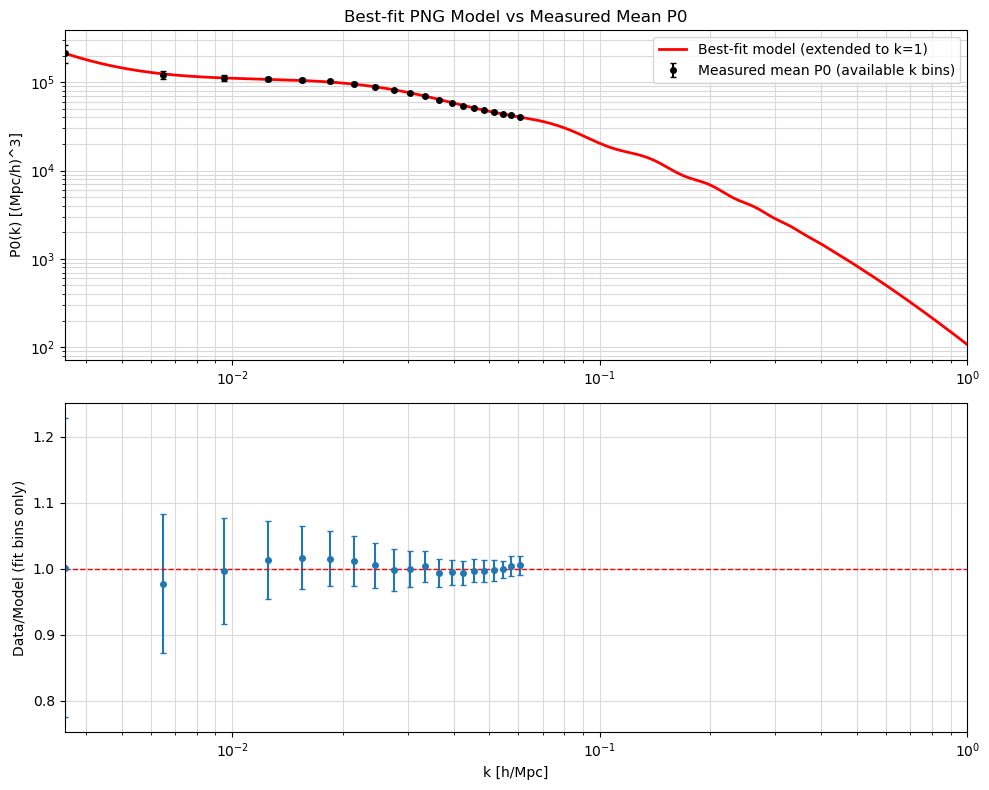

上图展示范围已扩到 k_max = 1.0
数据点最大 k = 0.0605，其后区间仅显示模型外推。


In [11]:
# 2) 手动画 Data vs Best-fit（便于快速检查）
# 目标：按你的要求把图的展示范围扩到 k=1（数据范围外仅显示模型外推）

# 先在“拟合用的 k 网格”上评估理论（用于 ratio）
_ = theory(**bestfit_params)
model_p0_fitgrid = np.asarray(theory.power[0])

# 再在更细、更宽的 k 网格上评估理论（用于上图连续曲线）
k_plot = np.geomspace(k_values.min(), PK_PLOT_KMAX, PK_PLOT_NPTS)
template_plot = FixedPowerSpectrumTemplate(z=UNIT_Z, fiducial=cosmo_unit)
theory_plot = PNGTracerPowerSpectrumMultipoles(k=k_plot, template=template_plot, mode='b-p')

# 与拟合设置保持一致：p 固定、sn0 固定、sigmas 放开
# （注意：这里只是用 best-fit 参数画曲线，不再重新拟合）
theory_plot.init.params['p'].update(fixed=True, value=FIXED_P)
theory_plot.init.params['sn0'].update(fixed=True, value=FIXED_SN0)
theory_plot.init.params['sigmas'].update(fixed=False, value=FIXED_SIGMAS)

theory_plot(**bestfit_params)
model_p0_plot = np.asarray(theory_plot.power[0])

# 用 mock 样本计算误差条
err_p0 = np.std(p0_mocks, axis=0, ddof=1)

plt.figure(figsize=(10, 8))

ax1 = plt.subplot(2, 1, 1)
ax1.errorbar(k_values, p0_mean, yerr=err_p0, fmt='o', ms=4, capsize=2,
             color='black', label='Measured mean P0 (available k bins)')
ax1.loglog(k_plot, model_p0_plot, 'r-', lw=2, label='Best-fit model (extended to k=1)')
ax1.set_xlim(k_values.min(), PK_PLOT_KMAX)
ax1.grid(True, which='both', ls='-', color='0.85')
ax1.set_ylabel('P0(k) [(Mpc/h)^3]')
ax1.set_title('Best-fit PNG Model vs Measured Mean P0')
ax1.legend()

ax2 = plt.subplot(2, 1, 2)
ratio = p0_mean / model_p0_fitgrid
ratio_err = err_p0 / np.abs(model_p0_fitgrid)
ax2.errorbar(k_values, ratio, yerr=ratio_err, fmt='o', ms=4, capsize=2, color='tab:blue')
ax2.axhline(1.0, color='red', ls='--', lw=1)
ax2.set_xscale('log')
ax2.set_xlim(k_values.min(), PK_PLOT_KMAX)
ax2.grid(True, which='both', ls='-', color='0.85')
ax2.set_xlabel('k [h/Mpc]')
ax2.set_ylabel('Data/Model (fit bins only)')

plt.tight_layout()
plt.show()

print(f'上图展示范围已扩到 k_max = {PK_PLOT_KMAX}')
print(f'数据点最大 k = {k_values.max():.4f}，其后区间仅显示模型外推。')


## 3.2 用 FFTLog 从 best-fit $P_0(k)$ 计算 $\xi_0(s)$（不使用 mcfit）

这一部分使用 FFTLog 算法把 3.1 的 best-fit 理论 `P0(k)` 变换成 `xi0(s)`。

核心关系：
\[
\xi_0(s)=\int_{k_{\min}}^{k_{\max}}\frac{k^2}{2\pi^2}P_0(k)j_0(ks)\,dk
\]

实现要点：
1. 明确给出积分上下限 `K_INT_MIN` 和 `K_INT_MAX`；
2. 在 `k` 边界做余弦 taper，减少硬截断导致的振铃；
3. 使用 `scipy.fft.fht`（FFTLog）做快速 Hankel 变换；
4. 与测量的 `pcf_rsd_N*.dat` 的 monopole 均值直接对比。

In [12]:
# =====================
# 3.2 参数区（FFTLog + IR 参数化窗口）
# =====================

# 积分上下限（统一改为 mission5 口径）
K_INT_MIN = 1e-4
K_INT_MAX = 20.0

# 盒长（决定 k_f = 2pi/L）；默认随当前数据目录自动判断
if '3gpc' in DATA_DIR.lower():
    BOX_SIZE_MODEL = 3000.0
elif '1gpc' in DATA_DIR.lower():
    BOX_SIZE_MODEL = 1000.0
else:
    BOX_SIZE_MODEL = 1000.0

K_FUND_MODEL = 2.0 * np.pi / BOX_SIZE_MODEL

# IR 参数化窗口（当前最佳口径）
# W(k)=1-exp(-(k/k_f)^x), k<k_f; W=1, k>=k_f
# x(L)=4*(L/1000)
USE_PARAM_IR_WINDOW = True
IR_WINDOW_PARAM_X = 4.0 * (BOX_SIZE_MODEL / 1000.0)

# FFTLog 网格参数
FFTLOG_N = 4096
FFTLOG_PADDING = 4.0
FFTLOG_MU = 0.5
FFTLOG_BIAS = 0.0
EDGE_TAPER_FRAC = 0.06  # 保留 FFTLog 内部 taper

# 2PCF 数据路径（自动匹配 DATA_DIR / FILE_GLOB）
# 规则：优先使用与 pk 对应的 pcf_masscut 目录，并把 FILE_GLOB 的前缀 pk_rsd 替换为 pcf_rsd
if '1gpc-UNIT-fnl100-fastpm' in DATA_DIR:
    pcf_dir_candidates = [
        '/pscratch/sd/l/lzy/1gpc-UNIT-fnl100-fastpm/pcf_masscut',
        '/pscratch/sd/l/lzy/1gpc-UNIT-fnl100-fastpm/pcf_masscut_fnl0',
    ]
elif '3gpc-UNIT-fastpm' in DATA_DIR:
    pcf_dir_candidates = [
        '/pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pcf_masscut',
    ]
else:
    pcf_dir_candidates = []

PCF_DIR = None
for d in pcf_dir_candidates:
    if os.path.isdir(d):
        PCF_DIR = d
        break
if PCF_DIR is None:
    raise RuntimeError(f'未找到可用 PCF_DIR，候选={pcf_dir_candidates}')

PCF_GLOB = FILE_GLOB.replace('pk_rsd', 'pcf_rsd')
PCF_REALIZATION_MIN = REALIZATION_MIN
PCF_REALIZATION_MAX = REALIZATION_MAX

print('3.2 参数已加载。')
print(f'积分范围 = [{K_INT_MIN}, {K_INT_MAX}] h/Mpc')
print(f'BOX_SIZE_MODEL = {BOX_SIZE_MODEL}, k_f = {K_FUND_MODEL:.6f}')
print(f'USE_PARAM_IR_WINDOW = {USE_PARAM_IR_WINDOW}, x = {IR_WINDOW_PARAM_X:.3f}')
print(f'FFTLOG_N = {FFTLOG_N}, padding = {FFTLOG_PADDING}')
print(f'PCF_DIR = {PCF_DIR}')
print(f'PCF_GLOB = {PCF_GLOB}')

# 与测量主比较使用哪条模型: 'window' 或 'baseline'
MODEL_COMPARE_MODE = 'window'
print(f'MODEL_COMPARE_MODE = {MODEL_COMPARE_MODE}')


3.2 参数已加载。
积分范围 = [0.0001, 20.0] h/Mpc
BOX_SIZE_MODEL = 3000.0, k_f = 0.002094
USE_PARAM_IR_WINDOW = True, x = 12.000
FFTLOG_N = 4096, padding = 4.0
PCF_DIR = /pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pcf_masscut
PCF_GLOB = pcf_rsd_3gpc_fnl100_N*.dat
MODEL_COMPARE_MODE = window


In [ ]:
from scipy.fft import fht, fhtoffset


def build_log_taper_window(k_array, kmin, kmax, frac):
    """
    在对数 k 空间构造余弦窗，控制积分上下限并减小边界振铃。
    """
    w = np.zeros_like(k_array, dtype=np.float64)
    lk = np.log(k_array)
    l0 = np.log(kmin)
    l1 = np.log(kmax)

    dl = frac * (l1 - l0)
    if dl <= 0:
        w[(k_array >= kmin) & (k_array <= kmax)] = 1.0
        return w

    left = l0 + dl
    right = l1 - dl

    m = (lk >= l0) & (lk < left)
    w[m] = 0.5 * (1.0 - np.cos(np.pi * (lk[m] - l0) / dl))

    m = (lk >= left) & (lk <= right)
    w[m] = 1.0

    m = (lk > right) & (lk <= l1)
    w[m] = 0.5 * (1.0 + np.cos(np.pi * (lk[m] - right) / dl))

    return w


def build_ir_param_window(k_array, k_fund, x_power):
    """
    构造 mission5 当前最佳 IR 参数化窗口（含归一化因子，作用于总 P0）：
    - k < k_f:  W(k) = [1 - exp(-(k/k_f)^x)] / [1 - exp(-1)]
    - k >= k_f: W(k) = 1

    归一化因子 1/[1-exp(-1)] 保证 W(k_f) = 1（窗口在 k_f 处连续）。
    """
    norm = 1.0 - np.exp(-1.0)  # ≈ 0.6321
    w = np.ones_like(k_array, dtype=np.float64)
    m = k_array < k_fund
    if np.any(m):
        ratio = np.clip(k_array[m] / k_fund, 0.0, None)
        w[m] = (1.0 - np.exp(-(ratio ** x_power))) / norm
    return w


def build_png_theory_on_kgrid(k_grid, fit_params):
    """
    在指定高分辨率 k 网格上评估 desilike 的 best-fit P0(k)。
    """
    template_fft = FixedPowerSpectrumTemplate(z=UNIT_Z, fiducial=cosmo_unit)
    theory_fft = PNGTracerPowerSpectrumMultipoles(k=k_grid, template=template_fft, mode='b-p')

    # 与 3.1 保持一致：固定 p、sn0、sigmas
    theory_fft.init.params['p'].update(fixed=True, value=FIXED_P)
    theory_fft.init.params['sn0'].update(fixed=True, value=FIXED_SN0)
    theory_fft.init.params['sigmas'].update(fixed=False, value=FIXED_SIGMAS)

    theory_fft(**fit_params)
    return np.asarray(theory_fft.power[0], dtype=np.float64)


def xi0_from_p0_fftlog(
    k_grid,
    p0_grid,
    kmin,
    kmax,
    mu=0.5,
    bias=0.0,
    taper_frac=0.06,
    use_param_ir_window=True,
    k_fund=None,
    x_power=None,
):
    """
    用 FFTLog 计算 xi0(s)，并支持 mission5 的参数化 IR 窗口。
    """
    # FFTLog 内部边界平滑窗（始终保留）
    window_taper = build_log_taper_window(k_grid, kmin, kmax, taper_frac)

    # 物理 IR 参数化窗口（默认启用）
    if use_param_ir_window:
        if k_fund is None or x_power is None:
            raise ValueError('use_param_ir_window=True 时必须提供 k_fund 与 x_power')
        window_ir = build_ir_param_window(k_grid, k_fund=k_fund, x_power=x_power)
    else:
        window_ir = np.ones_like(k_grid, dtype=np.float64)

    p0_eff = p0_grid * window_taper * window_ir

    dln = np.log(k_grid[1] / k_grid[0])
    offset = fhtoffset(dln, mu=mu, initial=0.0, bias=bias)

    # Hankel 输入序列：a(k)=k^(3/2)P0(k)
    a_in = (k_grid ** 1.5) * p0_eff
    A_out = fht(a_in, dln=dln, mu=mu, offset=offset, bias=bias)

    # 根据 FFTLog 网格关系恢复输出 s 网格
    n = k_grid.size
    j = np.arange(n)
    j_center = (n - 1) / 2.0
    ln_kc = 0.5 * (np.log(k_grid[0]) + np.log(k_grid[-1]))
    ln_s = -ln_kc + offset + (j - j_center) * dln
    s_grid = np.exp(ln_s)

    # 还原 xi0(s)
    coef = np.sqrt(np.pi / 2.0) / (2.0 * np.pi**2)
    xi0 = coef * A_out / (s_grid ** 1.5)

    return s_grid, xi0, window_taper, window_ir

In [14]:
# 如果前面还没跑到 best-fit，这里会明确报错
if 'bestfit_params' not in globals():
    raise RuntimeError('未找到 bestfit_params。请先运行 3.1 的拟合单元。')

# 2) baseline / window 各自使用独立 k 网格，避免口径混用
BASELINE_KMIN = K_FUND_MODEL
k_grid_baseline = np.geomspace(BASELINE_KMIN / FFTLOG_PADDING, K_INT_MAX * FFTLOG_PADDING, FFTLOG_N)
k_grid_window = np.geomspace(K_INT_MIN / FFTLOG_PADDING, K_INT_MAX * FFTLOG_PADDING, FFTLOG_N)

# 3) 在各自网格上评估 best-fit 理论 P0(k)
p0_model_baseline = build_png_theory_on_kgrid(k_grid_baseline, bestfit_params)
p0_model_window = build_png_theory_on_kgrid(k_grid_window, bestfit_params)

# 4a) baseline：按定义从 k_f=2pi/L 开始积分（仅保留 FFTLog taper）
s_fftlog_baseline, xi0_fftlog_baseline, k_taper_window_baseline, k_ir_window_baseline = xi0_from_p0_fftlog(
    k_grid=k_grid_baseline,
    p0_grid=p0_model_baseline,
    kmin=BASELINE_KMIN,
    kmax=K_INT_MAX,
    mu=FFTLOG_MU,
    bias=FFTLOG_BIAS,
    taper_frac=EDGE_TAPER_FRAC,
    use_param_ir_window=False,
    k_fund=K_FUND_MODEL,
    x_power=IR_WINDOW_PARAM_X,
)

# 4b) window：启用 mission5 最佳参数化窗口（kmin_global=1e-4）
s_fftlog_window, xi0_fftlog_window, k_taper_window_window, k_ir_window = xi0_from_p0_fftlog(
    k_grid=k_grid_window,
    p0_grid=p0_model_window,
    kmin=K_INT_MIN,
    kmax=K_INT_MAX,
    mu=FFTLOG_MU,
    bias=FFTLOG_BIAS,
    taper_frac=EDGE_TAPER_FRAC,
    use_param_ir_window=USE_PARAM_IR_WINDOW,
    k_fund=K_FUND_MODEL,
    x_power=IR_WINDOW_PARAM_X,
)

# 为兼容后续旧变量名：默认指向窗口版本
s_fftlog = s_fftlog_window
xi0_fftlog = xi0_fftlog_window

print('FFTLog 计算完成（baseline + window）。')
print(f'baseline: kmin=k_f={BASELINE_KMIN:.6f}, kmax={K_INT_MAX:.1f}')
print(f'window  : kmin_global={K_INT_MIN:.1e}, kmax={K_INT_MAX:.1f}, x={IR_WINDOW_PARAM_X:.3f}')


FFTLog 计算完成（baseline + window）。
baseline: kmin=k_f=0.002094, kmax=20.0
window  : kmin_global=1.0e-04, kmax=20.0, x=12.000


PCF 文件数 = 98
s_data 范围 = [56.0, 380.0] Mpc/h
Main compare mode = window


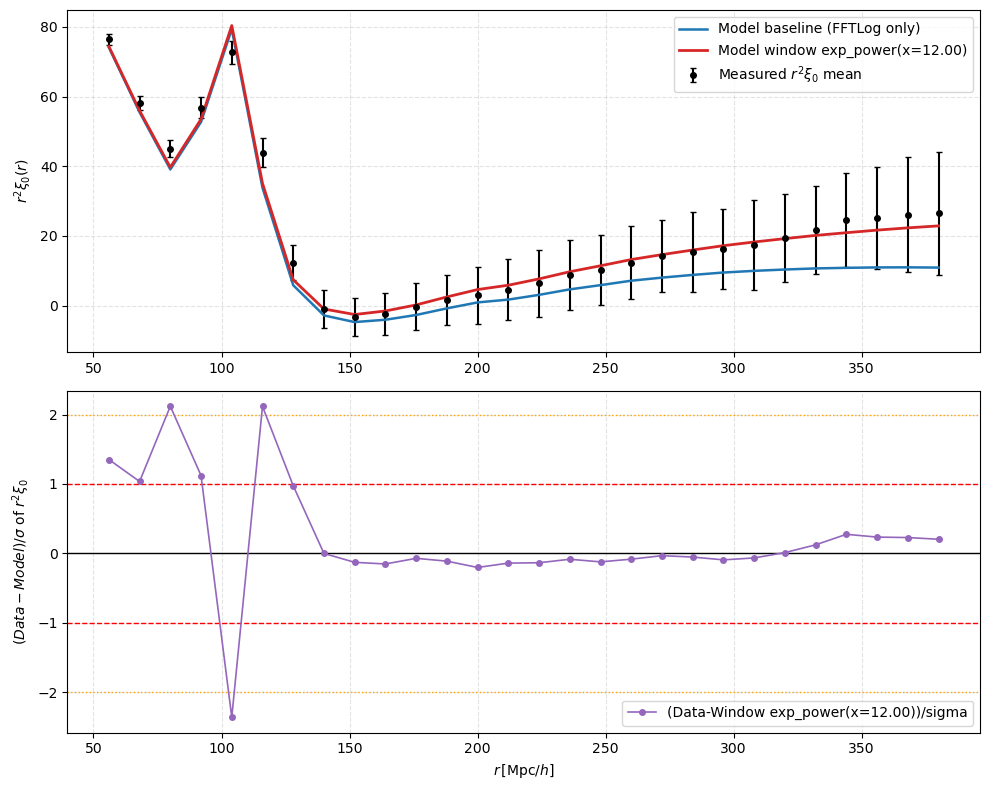

[baseline] |delta/sigma| mean = 0.851, max = 2.425
[window  ] |delta/sigma| mean = 0.487, max = 2.360


In [15]:
# 读取 pcf 数据并做均值
pcf_files_all = sorted(glob.glob(os.path.join(PCF_DIR, PCF_GLOB)), key=parse_realization_id)
pcf_files = [fp for fp in pcf_files_all if PCF_REALIZATION_MIN <= parse_realization_id(fp) <= PCF_REALIZATION_MAX]

if len(pcf_files) == 0:
    raise RuntimeError('未找到 2PCF 输入文件，请检查 PCF_DIR/PCF_GLOB。')

xi_list = []
for fp in pcf_files:
    arr = np.loadtxt(fp, comments='#')
    s_data = arr[:, 0]
    xi_list.append(arr[:, 3])

xi_stack = np.asarray(xi_list, dtype=np.float64)
xi_mean = np.mean(xi_stack, axis=0)
xi_std = np.std(xi_stack, axis=0, ddof=1)

# 插值模型到观测 s（baseline + window）
ord_b = np.argsort(s_fftlog_baseline)
ord_w = np.argsort(s_fftlog_window)
xi_model_baseline = np.interp(s_data, s_fftlog_baseline[ord_b], xi0_fftlog_baseline[ord_b])
xi_model_window = np.interp(s_data, s_fftlog_window[ord_w], xi0_fftlog_window[ord_w])

if MODEL_COMPARE_MODE.lower() == 'baseline':
    xi_model_main = xi_model_baseline
    main_label = 'Baseline (no IR window)'
else:
    xi_model_main = xi_model_window
    main_label = f'Window exp_power(x={IR_WINDOW_PARAM_X:.2f})'

print(f'PCF 文件数 = {len(pcf_files)}')
print(f's_data 范围 = [{s_data.min():.1f}, {s_data.max():.1f}] Mpc/h')
print(f'Main compare mode = {MODEL_COMPARE_MODE}')

# 画 (r, r^2 * xi)
r2_xi_data = s_data**2 * xi_mean
r2_xi_baseline = s_data**2 * xi_model_baseline
r2_xi_window = s_data**2 * xi_model_window
r2_xi_main = s_data**2 * xi_model_main
r2_xi_err = s_data**2 * xi_std

# 第二子图：主比较曲线的 sigma 偏差
delta_sigma_main = (r2_xi_data - r2_xi_main) / r2_xi_err

plt.figure(figsize=(10, 8))

# 上图：r^2 * xi 对比（同时画 baseline 和 window）
ax1 = plt.subplot(2, 1, 1)
ax1.errorbar(s_data, r2_xi_data, yerr=r2_xi_err, fmt='o', ms=4, capsize=2,
             color='black', label=r'Measured $r^2\xi_0$ mean')
ax1.plot(s_data, r2_xi_baseline, '-', lw=1.8, color='tab:blue',
         label='Model baseline (FFTLog only)')
ax1.plot(s_data, r2_xi_window, '-', lw=2.0, color='tab:red',
         label=f'Model window exp_power(x={IR_WINDOW_PARAM_X:.2f})')
ax1.set_ylabel(r'$r^2\xi_0(r)$')
ax1.grid(True, ls='--', alpha=0.35)
ax1.legend()

# 下图：主比较模式的 sigma 偏差
ax2 = plt.subplot(2, 1, 2)
ax2.axhline(0.0, color='black', ls='-', lw=1.0)
ax2.axhline(1.0, color='red', ls='--', lw=1.0)
ax2.axhline(-1.0, color='red', ls='--', lw=1.0)
ax2.axhline(2.0, color='orange', ls=':', lw=1.0)
ax2.axhline(-2.0, color='orange', ls=':', lw=1.0)
ax2.plot(s_data, delta_sigma_main, 'o-', ms=4, lw=1.2, color='tab:purple',
         label=f'(Data-{main_label})/sigma')
ax2.set_xlabel(r'$r\,[\mathrm{Mpc}/h]$')
ax2.set_ylabel(r'$(Data-Model)/\sigma$ of $r^2\xi_0$')
ax2.grid(True, ls='--', alpha=0.35)
ax2.legend()

plt.tight_layout()
plt.show()

# 同时输出 baseline/window 两种口径的统计
with np.errstate(divide='ignore', invalid='ignore'):
    delta_sigma_baseline = (r2_xi_data - r2_xi_baseline) / r2_xi_err
    delta_sigma_window = (r2_xi_data - r2_xi_window) / r2_xi_err

print('[baseline] |delta/sigma| mean = {:.3f}, max = {:.3f}'.format(
    np.nanmean(np.abs(delta_sigma_baseline)), np.nanmax(np.abs(delta_sigma_baseline))))
print('[window  ] |delta/sigma| mean = {:.3f}, max = {:.3f}'.format(
    np.nanmean(np.abs(delta_sigma_window)), np.nanmax(np.abs(delta_sigma_window))))


In [16]:
# 3.2 补充：固定 kmin=0.001，扫描 kmax 看大尺度收敛
KMIN_SCAN = 0.001
KMAX_SCAN_LIST = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 10.0]
LARGE_SCALE_MIN = 200.0   # 大尺度判据：r >= 200 Mpc/h

if 'bestfit_params' not in globals():
    raise RuntimeError('未找到 bestfit_params。请先运行 3.1 拟合单元。')

# 基于同一 best-fit，计算不同 kmax 的理论 r^2 xi 曲线（插值到数据 s）
r2_model_by_kmax = {}
for kmax in KMAX_SCAN_LIST:
    k_grid_scan = np.geomspace(KMIN_SCAN / FFTLOG_PADDING, kmax * FFTLOG_PADDING, FFTLOG_N)
    p0_scan = build_png_theory_on_kgrid(k_grid_scan, bestfit_params)
    s_scan, xi_scan, _ = xi0_from_p0_fftlog(
        k_grid=k_grid_scan,
        p0_grid=p0_scan,
        kmin=KMIN_SCAN,
        kmax=kmax,
        mu=FFTLOG_MU,
        bias=FFTLOG_BIAS,
        taper_frac=EDGE_TAPER_FRAC,
    )
    order = np.argsort(s_scan)
    xi_on_data = np.interp(s_data, s_scan[order], xi_scan[order])
    r2_model_by_kmax[kmax] = s_data**2 * xi_on_data

# 以最大 kmax=10 作为“近似参考曲线”评估收敛
kmax_ref = max(KMAX_SCAN_LIST)
r2_ref = r2_model_by_kmax[kmax_ref]
mask_large = s_data >= LARGE_SCALE_MIN

print(f'收敛评估区间: r >= {LARGE_SCALE_MIN:.0f} Mpc/h, 点数 = {mask_large.sum()}')
print()
print('[相对参考曲线 kmax=10 的差异]')
print('kmax   RMS(|Δ|)     RMS(|Δ|/σ_data)   Max(|Δ|)')

conv_stats = []
for kmax in KMAX_SCAN_LIST:
    delta = r2_model_by_kmax[kmax] - r2_ref
    rms_abs = np.sqrt(np.mean(delta[mask_large]**2))
    rms_sigma = np.sqrt(np.mean((delta[mask_large] / r2_xi_err[mask_large])**2))
    max_abs = np.max(np.abs(delta[mask_large]))
    conv_stats.append((kmax, rms_abs, rms_sigma, max_abs))
    print(f'{kmax:<5.1f}  {rms_abs:>10.4f}  {rms_sigma:>14.4f}  {max_abs:>10.4f}')

print()
print('[相邻 kmax 的变化量]')
print('k_prev -> k_now : RMS(|Δ|/σ_data)')
step_stats = []
for i in range(1, len(KMAX_SCAN_LIST)):
    kp = KMAX_SCAN_LIST[i - 1]
    kn = KMAX_SCAN_LIST[i]
    d = r2_model_by_kmax[kn] - r2_model_by_kmax[kp]
    rms_step = np.sqrt(np.mean((d[mask_large] / r2_xi_err[mask_large])**2))
    step_stats.append((kp, kn, rms_step))
    print(f'{kp:>4.1f} -> {kn:<4.1f} : {rms_step:.4f}')

# 画图1：不同 kmax 下的 r^2 xi 理论曲线（只画代表值避免太乱）
show_kmax = [0.3, 0.7, 1.0, 2.0, 5.0, 10.0]
plt.figure(figsize=(10, 6))
plt.errorbar(s_data, r2_xi_data, yerr=r2_xi_err, fmt='o', ms=3, capsize=2,
             color='black', alpha=0.75, label=r'Measured $r^2\xi_0$')
for kmax in show_kmax:
    plt.plot(s_data, r2_model_by_kmax[kmax], lw=1.8, label=f'kmax={kmax}')
plt.axvline(LARGE_SCALE_MIN, color='gray', ls='--', lw=1)
plt.xlabel(r'$r\,[\mathrm{Mpc}/h]$')
plt.ylabel(r'$r^2\xi_0(r)$')
plt.title('kmax scan (kmin fixed to 0.001)')
plt.grid(True, ls='--', alpha=0.35)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# 画图2：收敛量化（RMS sigma）随 kmax
k_arr = np.array([x[0] for x in conv_stats])
rms_sigma_arr = np.array([x[2] for x in conv_stats])
plt.figure(figsize=(8, 4.8))
plt.plot(k_arr, rms_sigma_arr, 'o-', color='tab:blue')
plt.axhline(0.5, color='orange', ls='--', lw=1, label='0.5 sigma RMS (rough)')
plt.axhline(0.2, color='red', ls=':', lw=1, label='0.2 sigma RMS (strict)')
plt.xlabel('kmax [h/Mpc]')
plt.ylabel(r'RMS$(|\Delta|/\sigma_{data})$ on large scales')
plt.title(r'Convergence vs $k_{\max}$ (r >= 200 Mpc/h)')
plt.grid(True, ls='--', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

# 给出分级结论
cand_rough = [x for x in conv_stats if x[2] < 0.5]
cand_strict = [x for x in conv_stats if x[2] < 0.2]
if cand_rough:
    print(f'结论（大致收敛）: kmax >= {cand_rough[0][0]:.1f} 时，大尺度达到 <0.5σ RMS。')
else:
    print('结论（大致收敛）: 本扫描范围内尚未达到 <0.5σ RMS。')
if cand_strict:
    print(f'结论（严格收敛）: kmax >= {cand_strict[0][0]:.1f} 时，大尺度达到 <0.2σ RMS。')
else:
    print('结论（严格收敛）: 本扫描范围内尚未达到 <0.2σ RMS。')


ValueError: use_param_ir_window=True 时必须提供 k_fund 与 x_power